<a href="https://colab.research.google.com/github/Sneha17A/ML_Projects/blob/main/HandBag_Shoes_Classifier_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Building Handbags-Shoes Classifier with Convolutional neural network

In [1]:
import os
import json
import math
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import losses
from keras import ops
from keras import optimizers
from keras.optimizers import schedules
from keras import metrics
from keras.applications.imagenet_utils import decode_predictions
import keras_hub
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from keras.layers import Lambda
import pandas as pd

In [2]:
!!pip install -q git+https://github.com/keras-team/keras-hub.git
!!pip install -q --upgrade keras

['\x1b[?25l   \x1b━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\x1b \x1b0.0/1.6 MB\x1b \x1b?\x1b eta \x1b-:--:--\x1b',
 '\x1b[2K   \x1b━━━━━━━━\x1b\x1b╸\x1b\x1b━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\x1b \x1b0.4/1.6 MB\x1b \x1b11.8 MB/s\x1b eta \x1b0:00:01\x1b',
 '\x1b[2K   \x1b━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\x1b\x1b╸\x1b \x1b1.6/1.6 MB\x1b \x1b28.4 MB/s\x1b eta \x1b0:00:01\x1b',
 '\x1b[2K   \x1b━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\x1b \x1b1.6/1.6 MB\x1b \x1b19.4 MB/s\x1b eta \x1b0:00:00\x1b',
 "\x1b[?25h\x1bERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.",
 'keras-nlp 0.26.0 requires keras-hub==0.26.0, but you have keras-hub 0.30.0.dev0 which is incompatible.\x1b\x1b',
 '\x1b']

In [3]:
keras.utils.set_random_seed(42)

In [4]:
!wget -q -P ./ https://www.dropbox.com/s/w07liww46kgxo1m/handbags-shoes.zip
!unzip -qq handbags-shoes.zip

Data Preprocessing

MNIST has 60K training examples.
now with 200 images..

In [5]:
import os, shutil, pathlib
base_dir = pathlib.Path("/content/handbags-shoes")

for category in ('handbags','shoes'):
  fnames = os.listdir(base_dir / category)
  dir = base_dir/'train'/category
  os.makedirs(dir)
  #first 50 example for training set
  for fname in fnames[:50]:
    shutil.copyfile(src=base_dir/category/fname, dst=dir/fname)
  dir = base_dir/'validation'/category
  os.makedirs(dir)
  #next 25 examples for validation test
  for fname in fnames[50:70]:
    shutil.copyfile(src=base_dir/category/fname, dst=dir/fname)
  dir = base_dir/'test'/category
  os.makedirs(dir)
  #remaining examples for test set
  for fname in fnames[75:]:
    shutil.copyfile(src=base_dir/category/fname, dst=dir/fname)

It creates directory struture

In [6]:
!find /content/handbags-shoes -type d

/content/handbags-shoes
/content/handbags-shoes/handbags
/content/handbags-shoes/.ipynb_checkpoints
/content/handbags-shoes/test
/content/handbags-shoes/test/handbags
/content/handbags-shoes/test/shoes
/content/handbags-shoes/validation
/content/handbags-shoes/validation/handbags
/content/handbags-shoes/validation/shoes
/content/handbags-shoes/train
/content/handbags-shoes/train/handbags
/content/handbags-shoes/train/shoes
/content/handbags-shoes/shoes


It is JPEG data. it has to convert to tensors. resize them to a standard size. group them into batches. keras has a single function to do all these actions

In [7]:
train_dataset = keras.utils.image_dataset_from_directory(
    base_dir /'train',
    image_size=(224,224),
    batch_size=32
)
validation_dataset = keras.utils.image_dataset_from_directory(
    base_dir /'validation',
    image_size=(224,224),
    batch_size=32
)
test_dataset = keras.utils.image_dataset_from_directory(
    base_dir /'test',
    image_size=(224,224),
    batch_size=32
)

Found 97 files belonging to 2 classes.
Found 40 files belonging to 2 classes.
Found 39 files belonging to 2 classes.


In [8]:
for images,_ in train_dataset.take(1):
  print(images[0].shape)

(224, 224, 3)


In [9]:
num_classes = 2
def preprocess_data(image,label):
  label = tf.one_hot(label,num_classes)
  return image, label
train_dataset = train_dataset.map(preprocess_data)
validate_dataset = validation_dataset.map(preprocess_data)
test_dataset = test_dataset.map(preprocess_data)
for images,labels in train_dataset.take(1):
  print("Image shape:", images.shape)
  print("Label shape:", labels.shape)

Image shape: (32, 224, 224, 3)
Label shape: (32, 2)


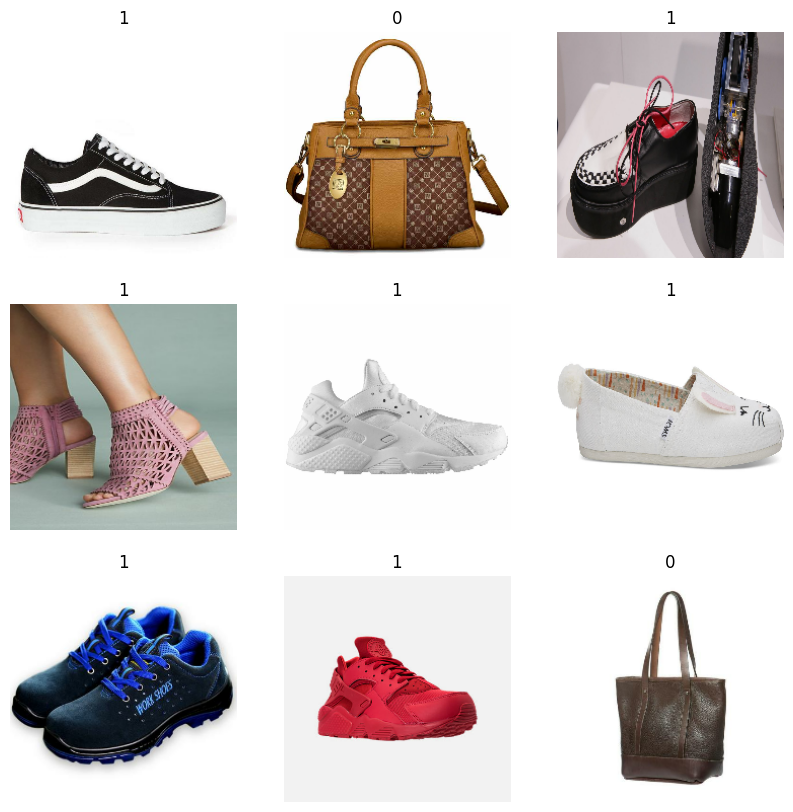

In [10]:
#few examples

plt.figure(figsize=(10,10))
for images, labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(int(tf.argmax(labels[i]==1)))
    plt.axis("off")

In [11]:
patch_size = 16
image_size = 224

In [12]:
def get_patches(images,patch_size=16):
  input_shape = tf.shape(images)
  batch_size = input_shape[0]
  height = input_shape[1]
  width = input_shape[2]
  channels = input_shape[3]
  num_patches_h = height//patch_size
  num_patches_w = width//patch_size
  patches = tf.image.extract_patches(images=images,
                                   sizes=[1,patch_size,patch_size,1],
                                   strides=[1,patch_size,patch_size,1],
                                   rates=[1,1,1,1],
                                   padding='VALID')
  patches = tf.reshape(tf.cast(patches,dtype=tf.float32),
                       (
                           batch_size,
                           num_patches_h*num_patches_w,
                           patch_size*patch_size*channels
                       ),
                       )
  return patches

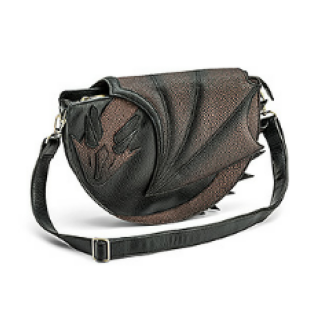

In [13]:
for images, _ in train_dataset.take(1):
  plt.figure(figsize=(4,4))
  resized_image = keras.ops.image.resize(
      keras.ops.convert_to_tensor([images[0]]),
      (image_size,image_size)
  )
  no_channels = keras.ops.shape(resized_image)[-1]
  plt.imshow(images[0].numpy().astype("uint8"))
  plt.axis("off")

Image size: 224 X 224
Patch size: 16 X 16
Patches per image: 196
Elements per patch: 768


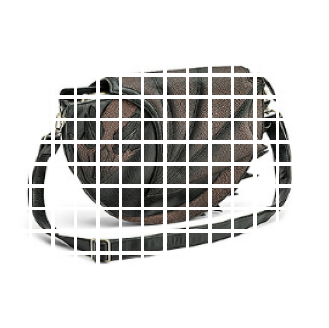

In [14]:
patches = get_patches(resized_image)
print(f"Image size: {image_size} X {image_size}")
print(f"Patch size: {patch_size} X {patch_size}")
print(f"Patches per image: {patches.shape[1]}")
print(f"Elements per patch: {patches.shape[-1]}")
n = int(np.sqrt(patches.shape[1]))
plt.figure(figsize=(4,4))
for i, patch in enumerate(patches[0]):
  ax = plt.subplot(n,n,i+1)
  patch_img = keras.ops.reshape(patch.numpy(),(16,16,no_channels))
  plt.imshow(keras.ops.convert_to_numpy(patch_img).astype("uint8"))
  plt.axis("off")

In [15]:
num_patches = (image_size//patch_size)**2
projection_dim = 64
num_heads = 8
transformer_units = [
    projection_dim*2,
    projection_dim,
]
num_transformer_layers = 2
mlp_head_units=[
    512,
    256,
]
num_classes = 2
input_shape = (image_size,image_size,3)

In [19]:
inputs = keras.Input(shape = input_shape)
layers = keras.layers
data_augmentation = keras.Sequential(
    [
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(0.1),
        keras.layers.RandomZoom(0.1),
        keras.layers.RandomTranslation(0.1,0.1),
    ])
x = data_augmentation(inputs)
patches = Lambda(get_patches,output_shape=(num_patches,patch_size*patch_size*3))(x)
projection = keras.layers.Dense(units=projection_dim)
position_embedding = layers.Embedding(
    input_dim=num_patches,output_dim=projection_dim
)
encoded_patches = projection(patches) + position_embedding(keras.ops.expand_dims(keras.ops.arange(start=0,stop=num_patches,step=1),
                                                                                axis=0))
for _ in range(num_transformer_layers):
  x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
  attention_output = layers.MultiHeadAttention(
      num_heads=num_heads,key_dim=projection_dim,dropout=0.1
  )(x1,x1)
  x2 = layers.Add()([attention_output, encoded_patches])
  x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
  for units in transformer_units:
    x3 = layers.Dense(units,activation = keras.activations.gelu)(x3)
    x3 = layers.Dropout(0.5)(x3)
  encoded_patches = layers.Add()([x3,x2])
representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
representation = layers.Flatten()(representation)
representation = layers.Dropout(0.5)(representation)
for units in mlp_head_units:
  representation = layers.Dense(units,activation=keras.activations.gelu)(representation)
  representation = layers.Dropout(0.5)(representation)
logits = layers.Dense(num_classes)(representation)
model = keras.Model(inputs=inputs,outputs=logits)


In [21]:
optimizer = keras.optimizers.AdamW(
    learning_rate=0.001
)
model.compile(optimizer=optimizer,
              loss=keras.losses.CategoricalCrossentropy(from_logits=True),
              metrics=[keras.metrics.CategoricalAccuracy(name="accuracy"),
                       ],
)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 224, 224,  │          0 │ input_layer_5[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 196, 768)  │          0 │ sequential_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 196, 64)   │     49,216 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 196, 64)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 196, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │    132,672 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 196, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 196, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 196, 128)  │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 196, 64)   │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 196, 64)   │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 196, 64)   │          0 │ dropout_2[0][0],  │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │    132,672 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 196, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 196, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 6,903,234 (26.33 MB)

 Trainable params: 6,903,234 (26.33 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
sample_input = tf.zeros((32,image_size,image_size,3))
model(sample_input)
history = model.fit(train_dataset,
          epochs=40,
          validation_data=validate_dataset,
          batch_size = 32
          )

Epoch 1/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.4227 - loss: 8.6369 - val_accuracy: 0.5000 - val_loss: 4.1060
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.4639 - loss: 4.4743 - val_accuracy: 0.5000 - val_loss: 1.6426
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.4330 - loss: 5.2406 - val_accuracy: 0.5000 - val_loss: 1.3779
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5258 - loss: 4.3670 - val_accuracy: 0.5000 - val_loss: 3.1213
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.4948 - loss: 4.5498 - val_accuracy: 0.5000 - val_loss: 0.6942
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.5361 - loss: 4.7749 - val_accuracy: 0.5000 - val_loss: 1.4613
Epoch 7/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.4124 - loss: 5.6908 - val_accuracy: 0.5000 - val_loss: 2.3548
Epoch 8/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.5773 - loss: 4.1229 - val_accuracy: 0.5000 - val_loss: 1.0949
Epoch 9/